upsampling, down sampling,soft max function, sigmoid function, logistic regression, True positive, true negative, false positive, false negative, f1 score, ROC curve, AUC curve

# Upsampling vs. Downsampling

In data science, machine learning, and signal processing, **upsampling** and **downsampling** are techniques used to alter either the balance of a dataset or the sampling rate of a digital signal. 

Because these terms mean different things depending on your specific domain, here is the breakdown for both contexts.

---

## 1. In Machine Learning & Data Analytics (Resampling)
In this context, upsampling and downsampling are used to handle **imbalanced datasets** (e.g., a fraud detection dataset where 99% of transactions are legitimate and only 1% are fraudulent).

### **Upsampling (Oversampling)**
* **What it is:** Increasing the number of instances in the minority class.
* **How it works:** You either duplicate existing records from the minority class or synthetically generate new, similar data points using algorithms like **SMOTE** (Synthetic Minority Over-sampling Technique).
* **Pros:** You don't lose any valuable information from your dataset.
* **Cons:** Duplicating data can easily lead to **overfitting**, where the model memorizes the minority examples instead of learning a general pattern.

### **Downsampling (Undersampling)**
* **What it is:** Decreasing the number of instances in the majority class.
* **How it works:** You randomly select a subset of the majority class to match the smaller size of the minority class.
* **Pros:** It reduces the overall size of the dataset, which speeds up model training times and lowers computational costs.
* **Cons:** You throw away a lot of potentially useful information, which can lead to **underfitting** or a poorly generalized model.

---

## 2. In Signal & Image Processing (Digital Signals)
In signal processing, audio editing, and computer vision, these terms refer to changing the resolution, frame rate, or frequency of digital data.

### **Upsampling (Interpolation)**
* **What it is:** Increasing the sampling rate or resolution of a signal or image.
* **How it works:** You insert zeros or extra pixels between the existing data points and then use **interpolation** (mathematical averaging) to smooth out the gaps. 
* **Example:** Zooming in on a digital image or converting a low-resolution audio track to a higher sample rate. It adds more data points, but it cannot create completely new, authentic details out of thin air.

### **Downsampling (Decimation)**
* **What it is:** Decreasing the sampling rate or resolution of a signal or image.
* **How it works:** You discard data points at regular intervals. For example, keeping every 2nd or 3rd pixel/sample and throwing away the rest.
* **Example:** Lowering the resolution of a 4K video to 1080p so it streams faster, or converting a high-fidelity audio file into a compressed, smaller file size. 
* **Note:** To prevent distortion or jagged edges (**aliasing**), a low-pass filter is usually applied before discarding the data points.

---

## Summary Comparison

| Feature | Upsampling | Downsampling |
| :--- | :--- | :--- |
| **Data Goal (ML)** | Add instances to the minority class to fix imbalance. | Remove instances from the majority class to fix imbalance. |
| **Signal Goal** | Increase resolution or sample rate. | Decrease resolution or sample rate (reduces file size). |
| **Main Risk** | Overfitting (in ML); Blurriness (in images). | Loss of important information / aliasing in signals. |

# The Sigmoid Activation Function

The **Sigmoid function** (also known as the **Logistic function**) is a widely used activation function in machine learning and deep learning, particularly in binary classification problems.

It maps any real-valued number into a strict probability range between **0 and 1**.

---

## Mathematical Formula

The mathematical formula for the standard sigmoid function is:

$$f(x) = \frac{1}{1 + e^{-x}}$$

Where:
* $x$ is the input value.
* $e$ is Euler's number (approximately 2.71828).

---

## Core Properties

* **Bounded Output:** The output is always strictly within the open interval $(0, 1)$. 
  * As $x \to \infty$, $f(x) \to 1$
  * As $x \to -\infty$, $f(x) \to 0$
  * When $x = 0$, $f(x) = 0.5$
* **S-Shaped Curve:** The function produces a distinct, smooth "S" shape.
* **Differentiable:** It has a smooth derivative everywhere, which is crucial for gradient-based optimization methods like gradient descent. Its derivative can be cleanly expressed using its own output: 
  $$f'(x) = f(x)(1 - f(x))$$

---

## Visualizing the Sigmoid Curve



---

## Common Applications

1. **Binary Classification:** In Logistic Regression and neural networks, it converts raw model outputs (logits) into a probability score for a binary decision (e.g., predicting "Fraud" vs. "Not Fraud").
2. **Output Layer of Neural Networks:** Used when the network needs to predict a single probability value.

## Limitations

* **Vanishing Gradient Problem:** For very high or very low input values ($x$), the curve becomes nearly flat. This means the gradient (derivative) becomes extremely close to $0$, causing neural networks to stop learning during backpropagation.
* **Not Zero-Centered:** The outputs are always positive, which can make optimization during gradient descent less efficient compared to functions like `tanh`.

# The Softmax Activation Function

The **Softmax function** is a core activation function used in machine learning, specifically in the final layer of **multi-class classification** models (where you need to classify an input into one of three or more distinct categories).

While the Sigmoid function handles binary decisions, Softmax generalizes this to handle multiple classes by turning a vector of raw scores (called **logits**) into a probability distribution that sums up to **1**.

---

## Mathematical Formula

For a vector of raw scores $z$ with $K$ elements, the Softmax value for the $i$-th element is calculated as:

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

### What this means in plain English:
1. **Exponentiate ($e^{z_i}$):** Take Euler's number ($e \approx 2.71828$) to the power of each raw score. This ensures every resulting value is strictly positive and significantly amplifies larger scores.
2. **Normalize ($\sum e^{z_j}$):** Divide each exponentiated score by the sum of *all* exponentiated scores. This forces the final outputs to sum up exactly to 1.0 (or 100%).

---

## Concrete Example

Imagine a neural network trying to classify an image into one of three classes: **Cat**, **Dog**, or **Bird**. 
The final layer outputs raw scores (logits): $z = [2.0, 1.0, 0.1]$

Applying Softmax steps:
1. **Calculate exponents:** * $e^{2.0} \approx 7.39$
   * $e^{1.0} \approx 2.72$
   * $e^{0.1} \approx 1.11$
   * *Sum of exponents* = $7.39 + 2.72 + 1.11 = 11.22$

2. **Divide by the sum to get probabilities:**
   * **Cat:** $7.39 / 11.22 \approx \mathbf{0.658}$ (65.8%)
   * **Dog:** $2.72 / 11.22 \approx \mathbf{0.242}$ (24.2%)
   * **Bird:** $1.11 / 11.22 \approx \mathbf{0.099}$ (9.9%)

All probabilities are between 0 and 1, and $0.658 + 0.242 + 0.099 = 1.0$.

---

## Architecture Context



---

## Key Properties & Comparison

| Feature | Sigmoid | Softmax |
| :--- | :--- | :--- |
| **Use Case** | Binary Classification (2 classes) | Multi-Class Classification ($>2$ classes) |
| **Output Type** | Independent probabilities | Dependent probability distribution |
| **Sum of Outputs** | Does not need to sum to 1 | **Must sum to exactly 1.0** |
| **Behavior** | Evaluates each class score separately. | Mutually exclusive; a higher score for one class directly lowers the probability of the others. |

# Logistic Regression

Despite its name containing "regression," **Logistic Regression** is a fundamental supervised learning algorithm used for **classification** problems (most commonly binary classification, like predicting "Yes/No", "Spam/Not Spam", or "Default/No Default").

While Linear Regression predicts continuous numeric values, Logistic Regression predicts the **probability** that a given input belongs to a specific category.

---

## How It Works

Instead of fitting a straight line to the data points, Logistic Regression takes the linear combination of inputs and passes it through the **Sigmoid function**. This squashes any real-valued number into a probability score between $0$ and $1$.

### The Core Steps:
1. Calculate the linear score (logits), just like in linear regression:
   $$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$
2. Pass $z$ through the Sigmoid activation function to get the probability ($p$):
   $$p = \frac{1}{1 + e^{-z}}$$
3. Apply a decision threshold (usually $0.5$):
   * If $p \ge 0.5$, classify as **Class 1**.
   * If $p < 0.5$, classify as **Class 0**.

---

## Visual Difference: Linear vs. Logistic Regression



---

## Cost Function: Log Loss (Cross-Entropy)

We cannot use Mean Squared Error (MSE) for Logistic Regression because the Sigmoid function turns the error surface non-convex, meaning gradient descent could get stuck in local minima. 

Instead, we use **Log Loss** (also called Binary Cross-Entropy), which penalizes confident but incorrect predictions heavily:

$$J(\beta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(p^{(i)}) + (1 - y^{(i)}) \log(1 - p^{(i)}) \right]$$

Where:
* $m$ is the number of training examples.
* $y^{(i)}$ is the actual class label ($0$ or $1$).
* $p^{(i)}$ is the model's predicted probability.

---

## Summary Comparison

| Feature | Linear Regression | Logistic Regression |
| :--- | :--- | :--- |
| **Output Type** | Continuous value (e.g., House Price, Temperature). | Discrete class probability (e.g., Cat vs. Dog). |
| **Output Range** | $-\infty$ to $+\infty$ | $0$ to $1$ |
| **Core Equation** | $y = \beta_0 + \beta_1 x$ | $y = \text{Sigmoid}(\beta_0 + \beta_1 x)$ |
| **Loss Function** | Mean Squared Error (MSE) | Log Loss / Binary Cross-Entropy |

Model Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       104
           1       0.92      0.86      0.89        96

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



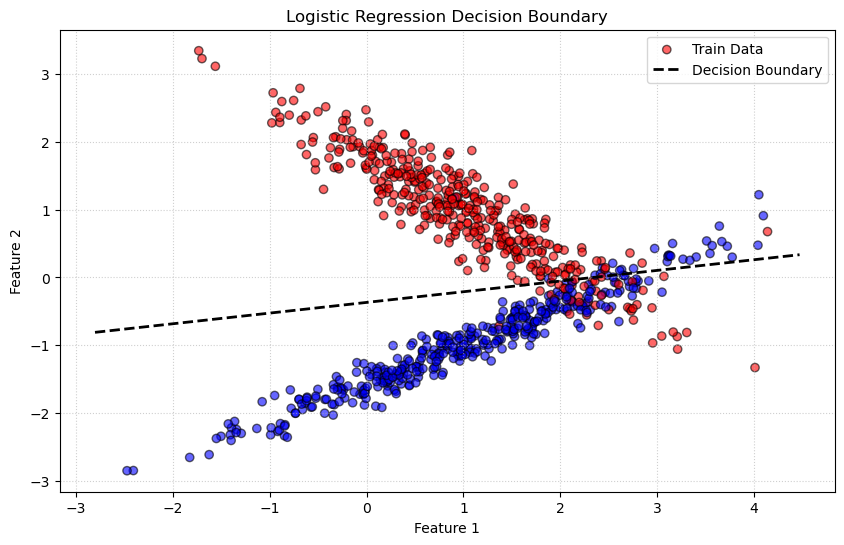

In [2]:
# # Hands-On Example: Logistic Regression in Python

# Below is a complete workflow demonstrating how to generate a synthetic classification dataset, train a Logistic Regression model using `scikit-learn`, and evaluate its performance.

# ```python
# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Generate a synthetic binary classification dataset
# We create 1000 samples with 2 informative features
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# 3. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Predicted probabilities for Class 1

# 6. Evaluate the model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Plot the decision boundary
plt.figure(figsize=(10, 6))

# Plot the training data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', alpha=0.6, edgecolors='k', label='Train Data')

# Calculate the decision boundary line (where score z = 0)
# Equation: beta_0 + beta_1*x1 + beta_2*x2 = 0  =>  x2 = -(beta_0 + beta_1*x1) / beta_2
ax = plt.gca()
x_vals = np.array(ax.get_xlim())
y_vals = -(model.intercept_[0] + model.coef_[0][0] * x_vals) / model.coef_[0][1]

plt.plot(x_vals, y_vals, '--', color='black', linewidth=2, label='Decision Boundary')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Understanding the Confusion Matrix: TP, TN, FP, FN

In binary classification, these four terms are the foundational building blocks used to evaluate how well a machine learning model is performing. 

To make this intuitive, let's use a real-world example: **A medical test checking if a patient has a specific disease.**

---

## The Four Core Metrics



### 1. True Positive (TP) — *The "Correct Hit"*
* **What it means:** The model predicted **Positive**, and the actual reality is **Positive**.
* **Medical Example:** The test says you *have* the disease, and you actually *do* have it.
* **Result:** A correct prediction.

### 2. True Negative (TN) — *The "Correct Rejection"*
* **What it means:** The model predicted **Negative**, and the actual reality is **Negative**.
* **Medical Example:** The test says you are *clear* of the disease, and you actually *don't* have it.
* **Result:** A correct prediction.

### 3. False Positive (FP) — *The "False Alarm" (Type I Error)*
* **What it means:** The model predicted **Positive**, but the actual reality is **Negative**.
* **Medical Example:** The test says you *have* the disease, but you are actually perfectly healthy. 
* **Result:** An incorrect prediction that causes unnecessary panic.

### 4. False Negative (FN) — *The "Miss" (Type II Error)*
* **What it means:** The model predicted **Negative**, but the actual reality is **Positive**.
* **Medical Example:** The test says you are *clear* of the disease, but you actually *do* have it.
* **Result:** An incorrect prediction that is highly dangerous because a sick patient goes untreated.

---

## Summary Cheat Sheet

| | Actual: POSITIVE | Actual: NEGATIVE |
| :--- | :--- | :--- |
| **Predicted: POSITIVE** | **True Positive (TP)** <br> *(Correctly caught)* | **False Positive (FP)** <br> *(False Alarm / Type I Error)* |
| **Predicted: NEGATIVE** | **False Negative (FN)** <br> *(Missed / Type II Error)* | **True Negative (TN)** <br> *(Correctly cleared)* |

---

## Why These Matter
These four numbers are used to calculate advanced evaluation metrics like:
* **Precision** $= \frac{TP}{TP + FP}$ *(When it predicts positive, how often is it right?)*
* **Recall / Sensitivity** $= \frac{TP}{TP + FN}$ *(Out of all actual positives, how many did it catch?)*
* **Accuracy** $= \frac{TP + TN}{TP + TN + FP + FN}$ *(What percentage of total guesses were correct?)*

# The F1-Score

The **F1-Score** is an evaluation metric used in binary and multi-class classification models. It measures a model's accuracy by calculating the **harmonic mean** of two other vital metrics: **Precision** and **Recall**.

The F1-Score gives you a single performance metric that balances the trade-off between false positives and false negatives.

---

## The Mathematical Formula

The formula for the F1-Score is:

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where:
* **Precision** $= \frac{TP}{TP + FP}$ (Out of all predicted positives, how many were actually positive?)
* **Recall** $= \frac{TP}{TP + FN}$ (Out of all actual positives, how many did the model find?)

### Why use the Harmonic Mean instead of a simple average?
A standard arithmetic average can be misleading. If a model has a Precision of $1.0$ but a Recall of $0.0$, a simple average gives it a score of $0.5$. The harmonic mean, however, punishes extreme imbalances and drops the F1-Score down to $0.0$. An F1-Score will only be high if **both** Precision and Recall are high.

---

## Visualizing the Trade-off



---

## Why Use F1-Score Instead of Accuracy?

Accuracy can be highly misleading when dealing with **imbalanced datasets**. 

Imagine a fraud detection dataset where **99%** of transactions are legitimate and only **1%** are fraudulent:
* A broken model that blindly guesses "Legitimate" for every single transaction will achieve **99% Accuracy**.
* However, its Recall for the fraud class will be **0%**, and its Precision will be **0%**, resulting in an **F1-Score of 0**. 

The F1-Score exposes this broken model, making it the preferred metric when the cost of missing positives (False Negatives) or falsely accusing negatives (False Positives) is high.

---

## Summary Cheat Sheet

| Metric | Focuses On | Best Used When... |
| :--- | :--- | :--- |
| **Accuracy** | Overall correctness across all classes. | The dataset is well-balanced. |
| **Precision** | Minimizing **False Positives** (False Alarms). | The cost of a false alarm is high (e.g., Spam Filters). |
| **Recall** | Minimizing **False Negatives** (Misses). | The cost of missing a target is critical (e.g., Cancer Detection). |
| **F1-Score** | Finding a balance between Precision & Recall. | The dataset is imbalanced and you care about both types of errors. |

# The ROC Curve and AUC

The **ROC Curve** (Receiver Operating Characteristic curve) is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. 

Paired with **AUC** (Area Under the Curve), it provides a performance metric for evaluating classification models regardless of the chosen classification threshold.

---

## The Core Components: TPR and FPR

The ROC curve plots the performance of a model by pitting two metrics against each other across all possible probability thresholds (from 0.0 to 1.0):

1. **True Positive Rate (TPR) / Recall / Sensitivity:**
   $$\text{TPR} = \frac{TP}{TP + FN}$$
   * *Meaning:* Out of all actual positive instances, how many did the model correctly find? (We want this high).

2. **False Positive Rate (FPR):**
   $$\text{FPR} = \frac{FP}{FP + TN} = 1 - \text{Specificity}$$
   * *Meaning:* Out of all actual negative instances, how many did the model falsely flag as positive? (We want this low).

---

## Visualizing the ROC Curve

The ROC curve plots **TPR on the y-axis** and **FPR on the x-axis**.



### How to Interpret the Graph:
* **The Diagonal Line (y = x):** Represents a completely random guesser (like flipping a coin). The AUC for a random model is $0.5$.
* **The Top-Left Corner (0, 1):** Represents a perfect classifier with $100\%$ True Positives and $0\%$ False Positives. The closer a model's curve bows toward this corner, the better it is.
* **The Curve Line:** Represents your model's trade-off. As you lower the threshold to catch more true positives, you inevitably pick up more false positives.

---

## Understanding AUC (Area Under the Curve)

**AUC** measures the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds.

* **$\text{AUC} = 1.0$:** A perfect model. It separates classes flawlessly.
* **$0.7 \le \text{AUC} < 0.9$:** An acceptable to good model with strong discriminative power.
* **$\text{AUC} = 0.5$:** No better than random guessing.
* **$\text{AUC} < 0.5$:** Worse than random guessing (effectively, the model is predicting the exact opposite of reality).

### Why use AUC over Accuracy?
AUC is **scale-invariant** (it measures how well predictions are ranked rather than their absolute values) and **classification-threshold-invariant** (it measures the quality of the model's predictions without forcing you to pick a single threshold like $0.5$).

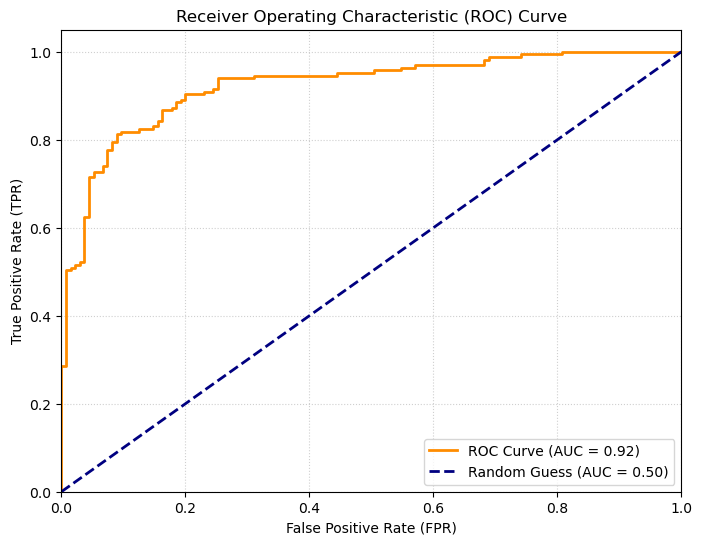

In [3]:
# # Hands-On Example: Plotting an ROC Curve in Python

# Below is a complete workflow demonstrating how to train a classifier, compute its prediction probabilities, and use `scikit-learn` and `matplotlib` to plot the ROC curve and compute the AUC.

# ```python
# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 2. Generate a synthetic binary dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Predict probabilities for the positive class (Class 1)
# predict_proba returns [prob_class_0, prob_class_1]. We slice [:, 1] to get prob_class_1.
y_probs = model.predict_proba(X_test)[:, 1]

# 6. Calculate True Positive Rate (TPR) and False Positive Rate (FPR) at various thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 7. Calculate the Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, y_probs)

# 8. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()